![lop](../../images/logo_diive1_128px.png)

# **Heatmap XYZ**

---
**Notebook version**: `1` (28 Mar 2026)  
**Author**: Lukas Hörtnagl (holukas@ethz.ch)

</br>

# **General usage**

```python
import diive as dv
dv.heatmapxyz(x=..., y=..., z=...)
```

</br>

# **Description**

- Plots a 2-D colour grid from three parallel Series: x coordinates, y coordinates, and z values (colour).
- Unlike `HeatmapDateTime`, there is no time axis — x and y can be any numeric coordinates (e.g. binned temperature and VPD).
- The typical workflow is to first aggregate data into bins using `dv.ga` (GridAggregator) and then pass the resulting long-format DataFrame to `dv.heatmapxyz`.
- This example uses 10 years of growing-season (May–Sep) eddy covariance data: mean daily air temperature (TA) and vapour pressure deficit (VPD) as the x/y axes, and mean daily net ecosystem productivity (NEP) as the colour variable.
- `dv.heatmapxyz()` is an alias for the class `diive.core.plotting.heatmap_xyz.HeatmapXYZ`, which is based on class `diive.core.plotting.heatmap_base.HeatmapBase`.

</br>

# **Imports**

In [2]:
import diive as dv
from diive.core.plotting.heatmap_base import HeatmapBase
from diive.core.dfun.frames import flatten_multiindex_all_df_cols
import importlib.metadata
from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import warnings
warnings.simplefilter("ignore", UserWarning)
version_diive = importlib.metadata.version("diive")
print(f"diive version: v{version_diive}")

diive version: v0.90.0


</br>

# **Docstring**

In [3]:
# help(dv.heatmapxyz)  # Accepts parameters for HeatmapBase
# help(HeatmapBase)

</br>

# **Load and prepare example data**

In [4]:
# Column names in the example dataset
ta_col = 'Tair_f'           # Air temperature (°C)
vpd_col = 'VPD_f'           # Vapour pressure deficit (hPa, converted to kPa below)
nee_col = 'NEE_CUT_REF_f'   # Net ecosystem exchange (µmol CO₂ m⁻² s⁻¹)
nep_col = 'NEP'             # Derived: NEP = −NEE  (net uptake is positive)

# Which columns go to which axis
xcol = ta_col   # x-axis: air temperature
ycol = vpd_col  # y-axis: vapour pressure deficit
zcol = nep_col  # colour: net ecosystem productivity

# Load example data
df_orig = dv.load_exampledata_parquet()

# Subset to growing season (May–Sep)
df_orig = df_orig.loc[(df_orig.index.month >= 5) & (df_orig.index.month <= 9)].copy()

# Select and convert relevant columns
df = df_orig[[nee_col, vpd_col, ta_col]].copy()
df[vpd_col] = df[vpd_col].multiply(0.1)          # hPa → kPa
df[nee_col] = df[nee_col].multiply(0.0792171)    # µmol CO₂ m⁻² s⁻¹ → g CO₂ m⁻² per 30 min
df[nep_col] = df[nee_col].multiply(-1)            # NEE → NEP  (positive = net uptake)

# Aggregate half-hourly data to daily values
df_daily = df.groupby(df.index.date).agg(
    {xcol: ['min', 'max', 'mean'],
     ycol: ['min', 'max', 'mean'],
     zcol: 'sum'}
)
df_daily = flatten_multiindex_all_df_cols(df=df_daily)

# Column names after flattening
x_col = f"{xcol}_mean"   # daily mean TA
y_col = f"{ycol}_mean"   # daily mean VPD
z_col = f"{zcol}_sum"   # daily mean NEP

df_daily[[x_col, y_col, z_col]]

Loaded .parquet file F:\Sync\luhk_work\20 - CODING\21 - DIIVE\diive\diive\configs\exampledata\exampledata_PARQUET_CH-DAV_FP2022.5_2013-2022_ID20230206154316_30MIN.parquet (0.055 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 


,Tair_f_mean,VPD_f_mean,NEP_sum
2013-05-01,9.219479,0.417779,15.005858
2013-05-02,8.978458,0.370242,14.177088
2013-05-03,6.429125,0.238192,11.084374
2013-05-04,5.023646,0.128138,13.992354
2013-05-05,7.170813,0.332985,9.564277
...,...,...,...
2022-09-26,4.073167,0.068367,3.217323
2022-09-27,2.706417,0.083098,2.850707
2022-09-28,2.851104,0.055188,3.510189
2022-09-29,2.376208,0.005192,0.989976


In [5]:
# Bin the daily data into a 10×10 quantile grid using GridAggregator
q = dv.ga(
    x=df_daily[x_col],
    y=df_daily[y_col],
    z=df_daily[z_col],
    binning_type='equal_width',
    n_bins=10,
    min_n_vals_per_bin=1,
    aggfunc='mean'
)

# df_agg_long: one row per (x-bin, y-bin) with the aggregated z value — use this for plotting
# (df_long contains the non-aggregated source data with bin assignments appended;
#  passing that to HeatmapXYZ would make pivot_table silently re-compute its own mean)
df_agg = q.df_agg_long

# Column names produced by GridAggregator
x_bin_col = f'BIN_{x_col}'   # bin centres for x
y_bin_col = f'BIN_{y_col}'   # bin centres for y
z_agg_col = z_col             # aggregated z values (column keeps the original Series name)

df_agg

,BIN_VPD_f_mean,BIN_Tair_f_mean,NEP_sum
0,0.00112,-4.192,1.661790
10,0.00112,-1.543,7.855691
11,0.19300,-1.543,7.091330
20,0.00112,1.106,8.296454
21,0.19300,1.106,10.313417
22,0.38600,1.106,7.772148
30,0.00112,3.755,8.798346
31,0.19300,3.755,10.561992
32,0.38600,3.755,9.953444
33,0.57800,3.755,9.210414


</br>

# (1) **Basic plot** with values overlaid on cells

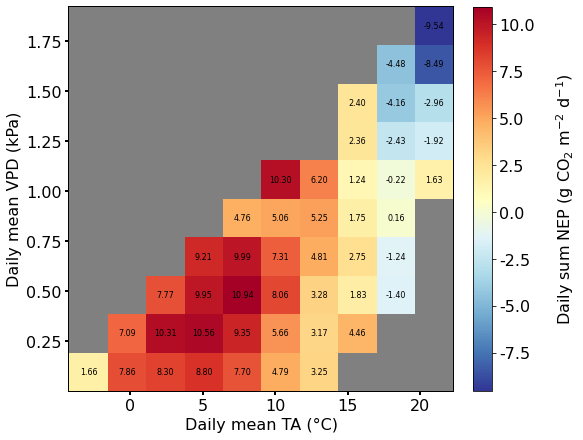

In [6]:
hm = dv.heatmapxyz(
    x=df_agg[x_bin_col],
    y=df_agg[y_bin_col],
    z=df_agg[z_agg_col],
    xlabel='Daily mean TA (°C)',
    ylabel='Daily mean VPD (kPa)',
    zlabel=r'Daily sum NEP (g CO$_2$ m$^{-2}$ d$^{-1}$)',
    show_values=True,
    show_values_n_dec_places=2,
    show_values_fontsize=8,
    cb_digits_after_comma=1,
    figsize=(8, 6)
)
hm.show()

In [ ]:
hm = dv.heatmapxyz(
    x=df[ta_col],
    y=df[vpd_col],
    z=df[nep_col],
    xlabel='Daily mean TA (°C)',
    ylabel='Daily mean VPD (kPa)',
    zlabel=r'Daily sum NEP (g CO$_2$ m$^{-2}$ d$^{-1}$)',
    show_values=True,
    show_values_n_dec_places=2,
    show_values_fontsize=8,
    cb_digits_after_comma=1,
    figsize=(8, 6)
)
hm.show()

## Get ax in which the plot was generated

In [7]:
this_ax = hm.get_ax()
this_ax

<Axes: xlabel='Daily mean TA (°C)', ylabel='Daily mean VPD (kPa)'>

## Get data that was used to create the plot

In [8]:
plot_df = hm.get_plot_data()
plot_df

</br>

# (2) **All parameters**

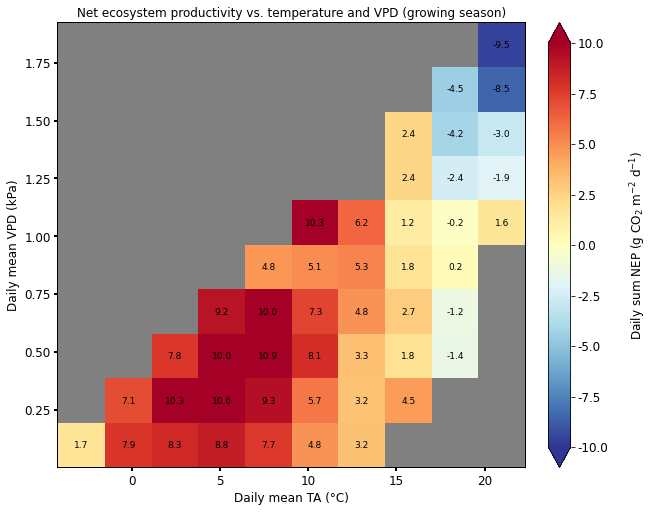

In [15]:
hm = dv.heatmapxyz(
    x=df_agg[x_bin_col],
    y=df_agg[y_bin_col],
    z=df_agg[z_agg_col],
    xlabel='Daily mean TA (°C)',
    ylabel='Daily mean VPD (kPa)',
    zlabel=r'Daily sum NEP (g CO$_2$ m$^{-2}$ d$^{-1}$)',
    xtickpos=None,       # None = automatic
    xticklabels=None,
    ytickpos=None,
    yticklabels=None,
    fig=None,
    figsize=(9, 7),
    figdpi=72,
    ax=None,
    title='Net ecosystem productivity vs. temperature and VPD (growing season)',
    vmin=-10,
    vmax=10,
    cb_digits_after_comma=1,
    cb_labelsize=12,
    cb_extend='both',
    axlabels_fontsize=12,
    ticks_labelsize=12,
    cmap='RdYlBu_r',
    color_bad='grey',
    show_colormap=True,
    show_values=True,
    show_values_fontsize=9,
    show_values_n_dec_places=1,
    show_grid=False,
    verbose=True
)
hm.show()

</br>

# (3) **Multiple heatmaps in one figure** using `.plot()`

Run `GridAggregator` twice on the same bins — once for the **mean** and once for the **standard deviation** — to show not only where NEP is highest but also where it is most variable.

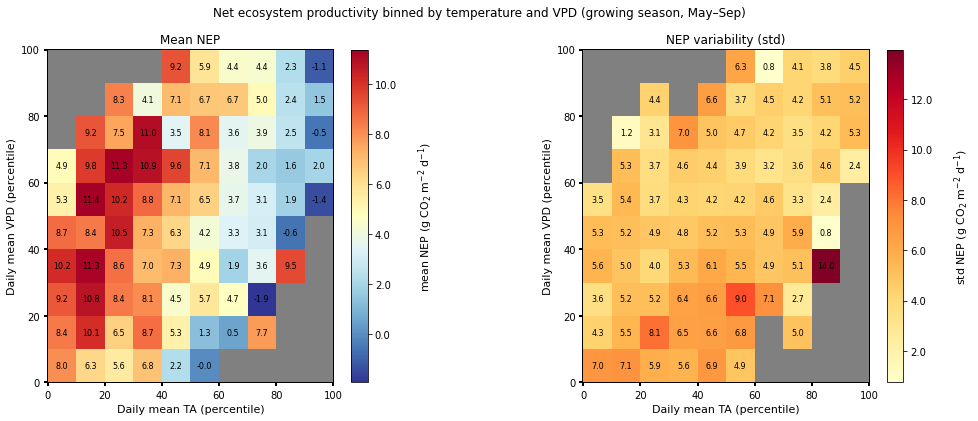

In [19]:
# Shared settings for both panels
shared = dict(
    xlabel='Daily mean TA (percentile)',
    ylabel='Daily mean VPD (percentile)',
    show_values=True,
    show_values_n_dec_places=1,
    show_values_fontsize=8,
    cb_digits_after_comma=1,
    axlabels_fontsize=11,
    ticks_labelsize=10,
    cb_labelsize=10
)

# GridAggregator: mean NEP per bin
q_mean = dv.ga(
    x=df_daily[x_col], y=df_daily[y_col], z=df_daily[z_col],
    binning_type='quantiles', n_bins=10, min_n_vals_per_bin=1, aggfunc='mean'
)

# GridAggregator: standard deviation of NEP per bin
q_std = dv.ga(
    x=df_daily[x_col], y=df_daily[y_col], z=df_daily[z_col],
    binning_type='quantiles', n_bins=10, min_n_vals_per_bin=1, aggfunc='std'
)

# Use df_agg_long (one pre-aggregated row per bin) — NOT df_long (raw observations)
df_agg_mean = q_mean.df_agg_long
df_agg_std = q_std.df_agg_long

# Figure layout
fig = plt.figure(facecolor='white', figsize=(16, 6), dpi=72)
gs = gridspec.GridSpec(1, 2)
gs.update(wspace=0.5)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])

dv.heatmapxyz(
    ax=ax1,
    x=df_agg_mean[x_bin_col],
    y=df_agg_mean[y_bin_col],
    z=df_agg_mean[z_agg_col],
    zlabel=r'mean NEP (g CO$_2$ m$^{-2}$ d$^{-1}$)',
    cmap='RdYlBu_r',
    **shared
).plot()

dv.heatmapxyz(
    ax=ax2,
    x=df_agg_std[x_bin_col],
    y=df_agg_std[y_bin_col],
    z=df_agg_std[z_agg_col],
    zlabel=r'std NEP (g CO$_2$ m$^{-2}$ d$^{-1}$)',
    cmap='YlOrRd',
    **shared
).plot()

ax1.set_title("Mean NEP", color='black')
ax2.set_title("NEP variability (std)", color='black')
fig.suptitle("Net ecosystem productivity binned by temperature and VPD (growing season, May–Sep)")
fig.show()

</br>

# **End of notebook**

In [20]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished {dt_string}")

Finished 2026-03-28 22:35:51
